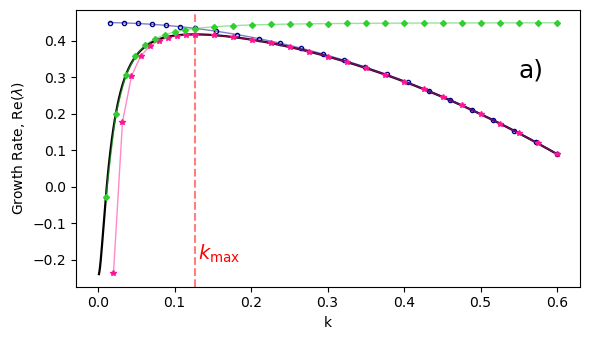

In [1]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
v = 182.5
B = 0.45
A = 1.0
d = 1.0

#k-grid for exact dispersion curve
k = np.linspace(0.001, 0.6, 4000)

#Define u (vegetated equilibrium)
disc = A**2 - 4*B**2
if disc <= 0:
    raise ValueError("Need A^2 > 4 B^2")
u = 2*B / (A - np.sqrt(disc))

#Exact growth rate Re(lambda)
alpha = ((1 + d)*k**2 + (1 + u**2) - B)**2 - k**2 * v**2 - 4 * (k**2 * (d * k**2 + 1 + u**2 + B*d) + B*(u**2 - 1))

beta = 2 * k * v * ((1 - d)*k**2 - (B + u**2 + 1))
gamma = B - (1 + d)*k**2 - (1 + u**2)

inner = 0.5 * (np.sqrt(alpha**2 + beta**2) + alpha)
inner = np.maximum(inner, 0.0)

real_L = 0.5 * (gamma + np.sqrt(inner))

#Find kmax from exact curve
idx = np.argmax(real_L)
kmax = k[idx]


#Approximation sample grids
k1 = np.concatenate([np.linspace(0.015, kmax, 6, endpoint=False), np.linspace(kmax, 0.6, 18)])

k2 = np.concatenate([np.linspace(0.02, kmax, 9, endpoint=False),np.linspace(kmax, 0.6, 20)])

k3 = np.concatenate([np.linspace(0.01, kmax, 9, endpoint=False),np.linspace(kmax, 0.6, 20)])


#k = O(1/v) approximation 
X = k3 * v

inner_sqrt = (u**8+ 4*(1 - 3*B)*u**6+ 2*(19*B**2 + X**2 - 10*B + 3)*u**4+ 
              4*(1 + (5*B + 1)*X**2 - 3*B**3 - 5*B**2 - B)*u**2+ (X**2 + (B + 1)**2)**2)

rad2 = (2*np.sqrt(inner_sqrt) + 2*B**2 + (-12*u**2 + 4)*B + 2*u**4 + 4*u**2
    - 2*X**2+ 2)
rad2 = np.maximum(rad2, 0.0)

expr = (B/2 - u**2/2 - 1/2 + np.sqrt(rad2)/4)

#k = O(1/sqrt(v)) approximation 
taylor_L3 = B - (1/v) * ((2 * B * u**2 * (B + 1 + u**2)) / (k2**2 * v) + k2**2 * v)


#Plot
plt.figure(figsize=(6, 3.5))

#Exact
plt.plot(k, real_L, label="real_L", color="black", linewidth=1.6)

#Vertical line at kmax
plt.axvline(kmax, color='red', linestyle='--', linewidth=1.5, alpha=0.5)

#k = O(1)
plt.plot(k1, B - k1**2, color='darkblue', linewidth=1, alpha=0.5)
plt.plot(k1, B - k1**2,linestyle='none', marker='o', markersize=3,
         markerfacecolor='none', markeredgecolor='darkblue',
         label=r"$k = O(1)$")

#k = O(1/sqrt(v))
plt.plot(k2, taylor_L3, color='deeppink', linewidth=1, alpha=0.5)
plt.plot(k2, taylor_L3,
         linestyle='none', marker='*', markersize=4,
         markerfacecolor='deeppink', markeredgecolor='deeppink',
         label=r"$k = O\!\left(v^{-1/2}\right)$")

#k = O(1/v)
plt.plot(k3, expr, color='limegreen', linewidth=1, alpha=0.5)
plt.plot(k3, expr,
         linestyle='none', marker='D', markersize=3,
         markerfacecolor='limegreen', markeredgecolor='limegreen',
         label=r"$k = O(v^{-1})$")

plt.xlabel("k")
plt.ylabel(r"Growth Rate, Re$(\lambda)$")
plt.text(0.13, -0.2, r"$k_{\max}$", color="red", fontsize =14)
plt.text(0.55, 0.3, "a)", fontsize=18)
plt.tight_layout()
plt.savefig("Approximation Plots Small Diffusion.pdf", format="pdf")
plt.show()

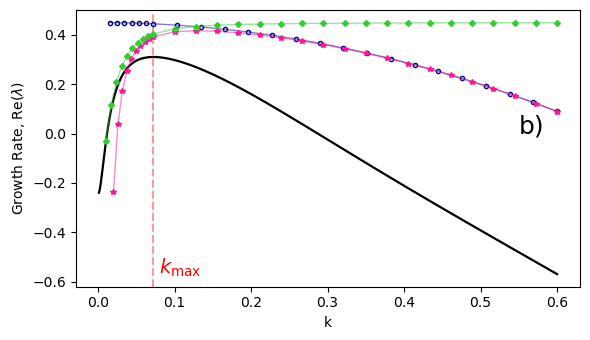

In [2]:
import numpy as np
import matplotlib.pyplot as plt

#Parameters
v = 182.5
B = 0.45
A = 1.0
d = 500.0

#k-grid for exact dispersion curve
k = np.linspace(0.001, 0.6, 4000)

#Define u (vegetated equilibrium)
disc = A**2 - 4*B**2
if disc <= 0:
    raise ValueError("Need A^2 > 4 B^2")
u = 2*B / (A - np.sqrt(disc))

#Exact growth rate Re(lambda
alpha = ((1 + d)*k**2 + (1 + u**2) - B)**2 - k**2 * v**2 - \
        4 * (k**2 * (d * k**2 + 1 + u**2 + B*d) + B*(u**2 - 1))

beta = 2 * k * v * ((1 - d)*k**2 - (B + u**2 + 1))
gamma = B - (1 + d)*k**2 - (1 + u**2)

inner = 0.5 * (np.sqrt(alpha**2 + beta**2) + alpha)
inner = np.maximum(inner, 0.0)

real_L = 0.5 * (gamma + np.sqrt(inner))

#Find kmax from exact curve
idx = np.argmax(real_L)
kmax = k[idx]

#Approximation sample grids
k1 = np.concatenate([np.linspace(0.015, kmax, 6, endpoint=False), np.linspace(kmax, 0.6, 18)])

k2 = np.concatenate([np.linspace(0.02, kmax, 9, endpoint=False),np.linspace(kmax, 0.6, 20)])

k3 = np.concatenate([np.linspace(0.01, kmax, 9, endpoint=False),np.linspace(kmax, 0.6, 20)])


#k = O(1/v) approximation 
X = k3 * v

inner_sqrt = (u**8+ 4*(1 - 3*B)*u**6+ 2*(19*B**2 + X**2 - 10*B + 3)*u**4+ 
              4*(1 + (5*B + 1)*X**2 - 3*B**3 - 5*B**2 - B)*u**2+ (X**2 + (B + 1)**2)**2)

rad2 = (2*np.sqrt(inner_sqrt) + 2*B**2 + (-12*u**2 + 4)*B + 2*u**4 + 4*u**2
    - 2*X**2+ 2)
rad2 = np.maximum(rad2, 0.0)

expr = (B/2 - u**2/2 - 1/2 + np.sqrt(rad2)/4)

#k = O(1/sqrt(v)) approximation 
taylor_L3 = B - (1/v) * ((2 * B * u**2 * (B + 1 + u**2)) / (k2**2 * v) + k2**2 * v)

#Plot
plt.figure(figsize=(6, 3.5))

#Exact
plt.plot(k, real_L, label="real_L", color="black", linewidth=1.6)

#Vertical line at kmax
plt.axvline(kmax, color='red', linestyle='--', label=f"kmax = {kmax:.4f}", linewidth=1.5, alpha=0.4)

#k = O(1)
plt.plot(k1, B - k1**2, color='darkblue', linewidth=1, alpha=0.5)
plt.plot(k1, B - k1**2,linestyle='none', marker='o', markersize=3,
         markerfacecolor='none', markeredgecolor='darkblue',
         label=r"$k = O(1)$")

#k = O(1/sqrt(v))
plt.plot(k2, taylor_L3, color='deeppink', linewidth=1, alpha=0.5)
plt.plot(k2, taylor_L3,
         linestyle='none', marker='*', markersize=4,
         markerfacecolor='deeppink', markeredgecolor='deeppink',
         label=r"$k = O\!\left(v^{-1/2}\right)$")

#k = O(1/v)
plt.plot(k3, expr, color='limegreen', linewidth=1, alpha=0.5)
plt.plot(k3, expr,
         linestyle='none', marker='D', markersize=3,
         markerfacecolor='limegreen', markeredgecolor='limegreen',
         label=r"$k = O(v^{-1})$")

plt.xlabel("k")
plt.ylabel(r"Growth Rate, Re$(\lambda)$")
plt.text(0.08, -0.57, r"$k_{\max}$", color="red", fontsize=14)
plt.text(0.55, 0, "b)", fontsize=18)
plt.tight_layout()
plt.savefig("Approximation Plots Big Diffusion.pdf", format="pdf")  
plt.show()